## 1. Importación de Dependencias y Carga de archivos CSV
Se importan las librerias y se cargan los dataset

In [1]:
import os
import numpy as np
import pandas as pd

PATH_TRAIN = 'dataset/processed/dataset_entrenamiento.csv'
PATH_VAL = 'dataset/processed/dataset_validacion.csv'
PATH_TEST = 'dataset/processed/dataset_prueba.csv'

df_train = pd.read_csv(PATH_TRAIN)
df_val = pd.read_csv(PATH_VAL)
df_test = pd.read_csv(PATH_TEST)

print(f"-> Set de Entrenamiento (2025):  {df_train.shape[0]} filas | {df_train.shape[1]} columnas")
print(f"-> Set de Validación (2026-V):   {df_val.shape[0]} filas | {df_val.shape[1]} columnas")
print(f"-> Set de Prueba (2026-O):       {df_test.shape[0]} filas | {df_test.shape[1]} columnas")

-> Set de Entrenamiento (2025):  144018 filas | 23 columnas
-> Set de Validación (2026-V):   27374 filas | 23 columnas
-> Set de Prueba (2026-O):       27374 filas | 23 columnas


## 2. Reducción de Dimensionalidad
Se descartan columnas para conservar únicamente las variables predictivas y el vector objetivo

In [2]:
columnas_a_descartar = [
    '_id', 'Fecha', 'ID region', 'Region', 
    'Unidad de comercializacion', 'Precio minimo', 
    'Precio maximo', 'Precio promedio', 'Precio_Promedio_Limpio', 'Volumen'
]

X_train = df_train.drop(columns=columnas_a_descartar + ['Precio_Promedio_Por_Kilo'])
y_train = df_train['Precio_Promedio_Por_Kilo']

X_val = df_val.drop(columns=columnas_a_descartar + ['Precio_Promedio_Por_Kilo'])
y_val = df_val['Precio_Promedio_Por_Kilo']

X_test = df_test.drop(columns=columnas_a_descartar + ['Precio_Promedio_Por_Kilo'])
y_test = df_test['Precio_Promedio_Por_Kilo']

print(f"Dimensiones finales de la matriz de entrada (X_train): {X_train.shape[1]} columnas de negocio conservadas.")    

Dimensiones finales de la matriz de entrada (X_train): 12 columnas de negocio conservadas.


## 3. Codificación Vectorial de Variables 
Se transforman los vectores de texto plano en matrices numéricas procesables. Aplica One-Hot Encoding a las variables de baja cardinalidad, y Target Encoding a las de alta cardinalidad

In [3]:
from category_encoders import TargetEncoder

X_train = X_train.drop(columns=['Dia_Semana_Nombre'])
X_val = X_val.drop(columns=['Dia_Semana_Nombre'])
X_test = X_test.drop(columns=['Dia_Semana_Nombre'])

baja_cardinalidad = ['Subsector', 'Estacion']
alta_cardinalidad = ['Mercado', 'Producto', 'Variedad / Tipo', 'Calidad', 'Origen']

print("Aplicando One-Hot Encoding a variables de baja cardinalidad...")
X_train = pd.get_dummies(X_train, columns=baja_cardinalidad, drop_first=True)
X_val = pd.get_dummies(X_val, columns=baja_cardinalidad, drop_first=True)
X_test = pd.get_dummies(X_test, columns=baja_cardinalidad, drop_first=True)

X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("Entrenando y aplicando Target Encoder en la arquitectura de variables...")
encoder = TargetEncoder(cols=alta_cardinalidad)

X_train_encoded = encoder.fit_transform(X_train, y_train)
X_val_encoded = encoder.transform(X_val)
X_test_encoded = encoder.transform(X_test)

print(f"-> Proceso completado. Columnas resultantes en X_train_encoded: {X_train_encoded.shape[1]}")

Aplicando One-Hot Encoding a variables de baja cardinalidad...
Entrenando y aplicando Target Encoder en la arquitectura de variables...
-> Proceso completado. Columnas resultantes en X_train_encoded: 13


## Fase 4: Estandarización y Escalamiento de Características
Se normalizan las escalas de las variables numéricas para garantizar condiciones equitativas

In [5]:
from sklearn.preprocessing import StandardScaler

print("Inicializando y aplicando escalamiento estándar sobre las matrices")
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print(f"-> Matrices escaladas exitosamente")
print(f"-> Estructura dimensional de X_train_scaled (NumPy Array): {X_train_scaled.shape}")

Inicializando y aplicando escalamiento estándar sobre las matrices
-> Matrices escaladas exitosamente
-> Estructura dimensional de X_train_scaled (NumPy Array): (144018, 13)


## 5. Entrenamiento de Modelos 
Se instancian los algoritmos de Regresión Ridge y Lasso para ajustar sus coeficientes lineales utilizando la data de entrenamiento

In [8]:
from sklearn.linear_model import Ridge, Lasso

print("Inicializando instancias de modelos Ridge y Lasso...")
model_ridge = Ridge(alpha=1.0, random_state=42)
model_lasso = Lasso(alpha=1.0, random_state=42)

print("Entrenando Modelo Ridge")
model_ridge.fit(X_train_scaled, y_train)

print("Entrenando Modelo Lasso")
model_lasso.fit(X_train_scaled, y_train)

print("-> Proceso de optimización completado para ambos algoritmos.")

Inicializando instancias de modelos Ridge y Lasso...
Entrenando Modelo Ridge
Entrenando Modelo Lasso
-> Proceso de optimización completado para ambos algoritmos.


## 6. Evaluación en Validación
Se calculan las métricas de regresión (MAE, RMSE, R²) en el conjunto de validación para comparar el rendimiento de ambos modelos y elegir al ganador

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Generando predicciones sobre el conjunto de validación (2026)")
preds_ridge = model_ridge.predict(X_val_scaled)
preds_lasso = model_lasso.predict(X_val_scaled)

mae_ridge = mean_absolute_error(y_val, preds_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_val, preds_ridge))
r2_ridge = r2_score(y_val, preds_ridge)

mae_lasso = mean_absolute_error(y_val, preds_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_val, preds_lasso))
r2_lasso = r2_score(y_val, preds_lasso)

print("\n=== RENDIMIENTO REGRESIÓN RIDGE ===")
print(f"-> MAE:  ${mae_ridge:.2f} CLP")
print(f"-> RMSE: ${rmse_ridge:.2f} CLP")
print(f"-> R²:   {r2_ridge * 100:.2f}%")

print("\n=== RENDIMIENTO REGRESIÓN LASSO ===")
print(f"-> MAE:  ${mae_lasso:.2f} CLP")
print(f"-> RMSE: ${rmse_lasso:.2f} CLP")
print(f"-> R²:   {r2_lasso * 100:.2f}%")

Generando predicciones sobre el conjunto de validación (2026)

=== RENDIMIENTO REGRESIÓN RIDGE ===
-> MAE:  $328.75 CLP
-> RMSE: $453.75 CLP
-> R²:   74.09%

=== RENDIMIENTO REGRESIÓN LASSO ===
-> MAE:  $328.64 CLP
-> RMSE: $453.85 CLP
-> R²:   74.08%


## 7. Análisis de Coeficientes e Importancia de Variables
Se extraen y grafican los pesos matemáticos del modelo Lasso para identificar qué factores encarecen o abaratan los productos y cuáles fueron eliminados

=== RADIOGRAFÍA DEL MODELO LASSO ===
-> Variables penalizadas y eliminadas por Lasso (Peso = 0): []



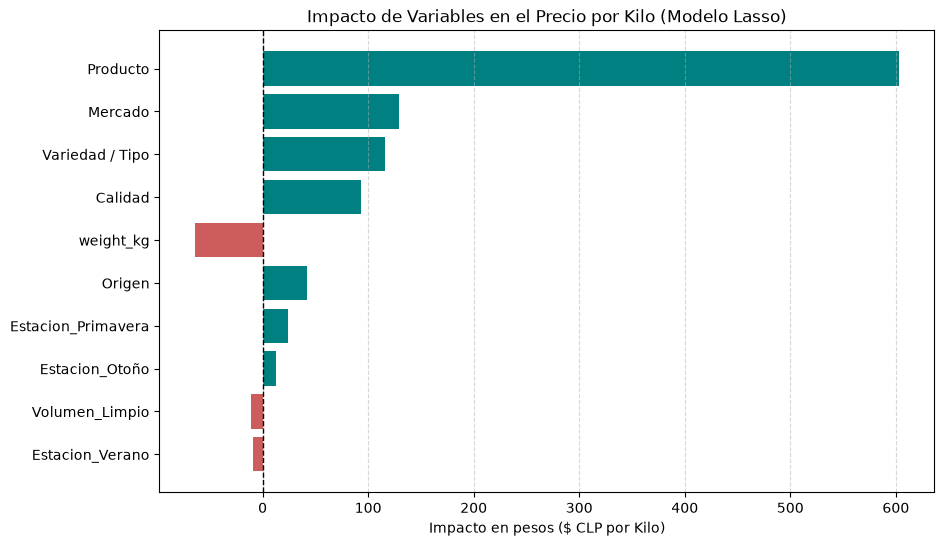

In [12]:
import matplotlib.pyplot as plt

nombres_variables = X_train_encoded.columns
coeficientes = model_lasso.coef_

df_importancia = pd.DataFrame({
    "Variable": nombres_variables,
    "Coeficiente": coeficientes,
    "Impacto_Absoluto": np.abs(coeficientes)
}).sort_values(by="Impacto_Absoluto", ascending=False)

print("=== RADIOGRAFÍA DEL MODELO LASSO ===")
variables_eliminadas = df_importancia[df_importancia["Coeficiente"] == 0]["Variable"].tolist()
print(f"-> Variables penalizadas y eliminadas por Lasso (Peso = 0): {variables_eliminadas}\n")

plt.figure(figsize=(10, 6))
top_variables = df_importancia.head(10) 

plt.barh(top_variables["Variable"], top_variables["Coeficiente"], 
         color=['teal' if c > 0 else 'indianred' for c in top_variables["Coeficiente"]])

plt.axvline(x=0, color='black', linestyle='--', linewidth=1) 
plt.title("Impacto de Variables en el Precio por Kilo (Modelo Lasso)")
plt.xlabel("Impacto en pesos ($ CLP por Kilo)")
plt.gca().invert_yaxis() 
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

## 8. Evaluación Final y Gráfico de Dispersión en el Dataset de Prueba
Se evalúa el rendimiento definitivo del modelo Lasso en el conjunto de prueba congelado y se grafican los valores reales contra los predichos.

Evaluando el rendimiento final en el dataset de prueba

--- Resultados Definitivos del Modelo de Regresión Lasso ---
MAE  : 346.27 CLP
MSE  : 300070.4
RMSE : 547.79 CLP
R²   : 72.10%


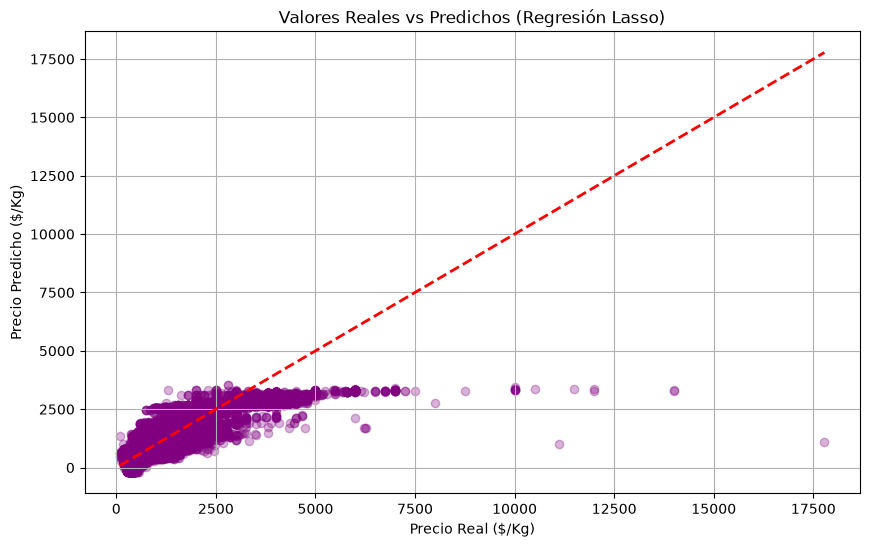

In [14]:
import matplotlib.pyplot as plt

print("Evaluando el rendimiento final en el dataset de prueba")
preds_finales = model_lasso.predict(X_test_scaled)

mae_final = mean_absolute_error(y_test, preds_finales)
mse_final = mean_squared_error(y_test, preds_finales)
rmse_final = np.sqrt(mse_final)
r2_final = r2_score(y_test, preds_finales)

print("\n--- Resultados Definitivos del Modelo de Regresión Lasso ---")
print(f"MAE  : {round(mae_final, 2)} CLP")
print(f"MSE  : {round(mse_final, 2)}")
print(f"RMSE : {round(rmse_final, 2)} CLP")
print(f"R²   : {round(r2_final, 4) * 100:.2f}%")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, preds_finales, alpha=0.3, color="purple")
plt.xlabel("Precio Real ($/Kg)")
plt.ylabel("Precio Predicho ($/Kg)")
plt.title("Valores Reales vs Predichos (Regresión Lasso)")

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.grid(True)
plt.show()